In [1]:
import torch
import evaluate
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [2]:
# --- 1. Load Dataset and Tokenizer ---
print("Loading IMDb dataset...")
imdb = load_dataset("imdb")

print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

Loading IMDb dataset...

Loading tokenizer...


In [3]:
# --- 2. Preprocessing Function ---
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)

print("\nTokenizing dataset...")
tokenized_imdb = imdb.map(preprocess_function, batched=True)


Tokenizing dataset...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
# --- 3. Create a smaller subset for faster training ---
train_dataset = tokenized_imdb["train"].shuffle(seed=42).select(range(2000))
eval_dataset = tokenized_imdb["test"].shuffle(seed=42).select(range(500))

print(f"\nUsing {len(train_dataset)} samples for training and {len(eval_dataset)} for evaluation.")



Using 2000 samples for training and 500 for evaluation.


In [5]:
# --- 4. Load Pre-trained Model ---
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [6]:
# --- 5. Define Evaluation Metric ---
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [7]:
# --- 6. Define Training Arguments ---
training_args = TrainingArguments(
    output_dir="my_bert_model",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3, # Increased to 3 epochs for a better graph
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

In [8]:
# --- 7. Instantiate the Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

C:\Users\Priangshu Paul\AppData\Local\Temp\ipykernel_31648\1802249806.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
[codecarbon WARNING @ 22:51:24] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 22:51:24] [setup] RAM Tracking...
[codecarbon INFO @ 22:51:24] [setup] CPU Tracking...
[codecarbon WARNING @ 22:51:26] We saw that you have a 13th Gen Intel(R) Core(TM) i5-13450HX but we don't know it. Please contact us.
[codecarbon WARNING @ 22:51:26] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 22:51:26] CPU Model on constant consumption mode: 13th Gen Intel(R) Core(TM) i5-13450HX
[codecarbon WARNING @ 22:51:26] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 22:51:26] [setup] GPU Tr

In [9]:
# --- 8. Start Fine-Tuning ---
print("\nStarting fine-tuning...")
trainer.train()


Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.285497,0.896000
2,0.292000,0.458187,0.896000
3,0.292000,0.459505,0.904000


[codecarbon INFO @ 22:51:52] Energy consumed for RAM : 0.000083 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 22:51:52] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:51:52] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 22:51:52] Energy consumed for all GPUs : 0.000362 kWh. Total GPU Power : 86.69070328942128 W
[codecarbon INFO @ 22:51:52] 0.000622 kWh of electricity used since the beginning.
[codecarbon INFO @ 22:52:07] Energy consumed for RAM : 0.000167 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 22:52:07] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:52:07] Energy consumed for All CPU : 0.000354 kWh
[codecarbon INFO @ 22:52:07] Energy consumed for all GPUs : 0.000760 kWh. Total GPU Power : 95.5275205365997 W
[codecarbon INFO @ 22:52:07] 0.001281 kWh of electricity used since the beginning.
[codecarbon INFO @ 22:52:22] Energy consumed for RAM : 0.000250 kWh. RAM Power : 20

TrainOutput(global_step=750, training_loss=0.22522256724039713, metrics={'train_runtime': 400.5736, 'train_samples_per_second': 14.979, 'train_steps_per_second': 1.872, 'total_flos': 1578666332160000.0, 'train_loss': 0.22522256724039713, 'epoch': 3.0})

In [10]:
# --- 9. Evaluate the Final Model ---
print("\nEvaluating the fine-tuned model...")
eval_results = trainer.evaluate()
print(f"\nFinal evaluation results: {eval_results}")


Evaluating the fine-tuned model...



Final evaluation results: {'eval_loss': 0.28549695014953613, 'eval_accuracy': 0.896, 'eval_runtime': 9.2865, 'eval_samples_per_second': 53.842, 'eval_steps_per_second': 6.784, 'epoch': 3.0}



Generating training graphs...


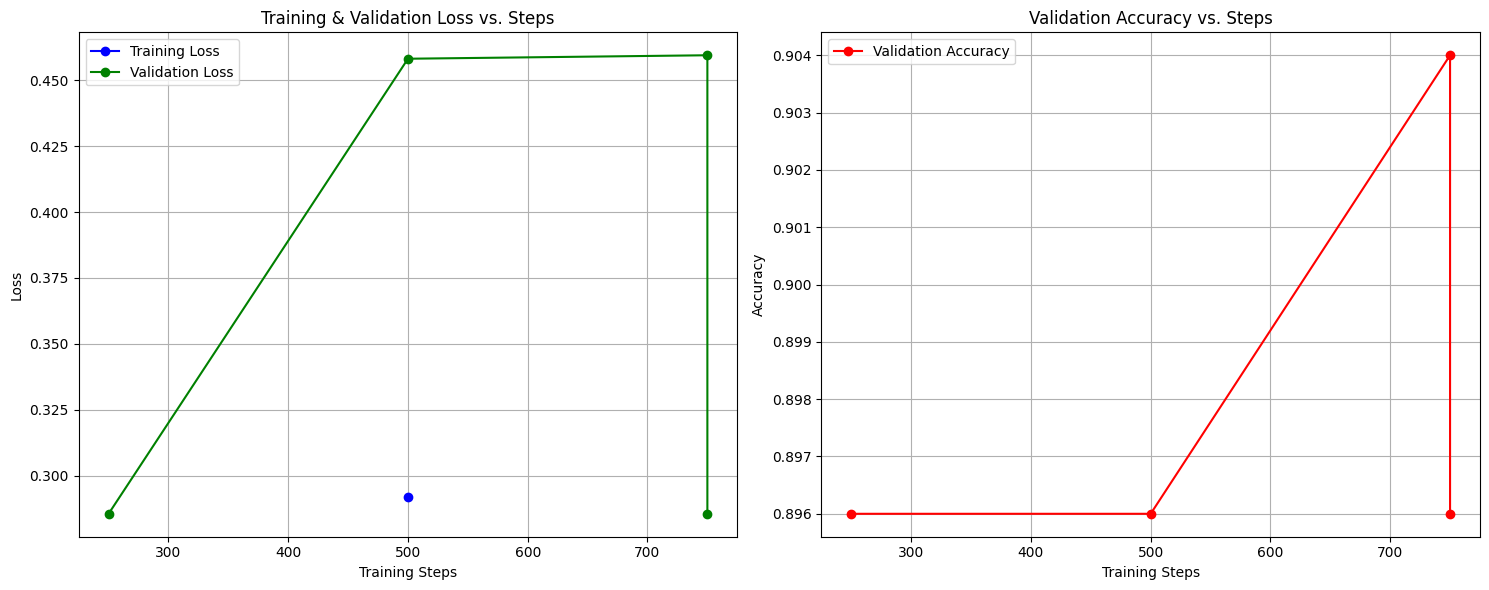

In [16]:
import matplotlib.pyplot as plt

# --- 10. (CORRECTED) Plotting the Training History ---
print("\nGenerating training graphs...")

# Extract the history from the trainer state
log_history = trainer.state.log_history

# Initialize lists to store metrics
train_losses = []
train_steps = []
val_losses = []
val_accuracies = []
eval_steps = []

# Parse the log history to separate training and evaluation logs
for log in log_history:
    if 'loss' in log:  # This indicates a training log
        train_losses.append(log['loss'])
        train_steps.append(log['step'])
    if 'eval_loss' in log:  # This indicates an evaluation log
        val_losses.append(log['eval_loss'])
        val_accuracies.append(log['eval_accuracy'])
        eval_steps.append(log['step'])

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Loss
ax1.plot(train_steps, train_losses, 'b-o', label='Training Loss')
ax1.plot(eval_steps, val_losses, 'g-o', label='Validation Loss')
ax1.set_title('Training & Validation Loss vs. Steps')
ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(eval_steps, val_accuracies, 'r-o', label='Validation Accuracy')
ax2.set_title('Validation Accuracy vs. Steps')
ax2.set_xlabel('Training Steps')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()